In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

df.to_csv("BostonHousing.csv", index=False)

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
print("Number of rows and columns:")
print(df.shape)

print("\nAttribute names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate records:")
print(df.duplicated().sum())

print("\nStatistical information:")
print(df.describe())

Number of rows and columns:
(506, 14)

Attribute names:
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']

Data types:
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

Missing values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Total missing values:
0

Duplicate records:
0

Statistical information:
             crim          zn       indus        chas         nox          rm         age         dis         rad         tax     ptratio  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000  506.

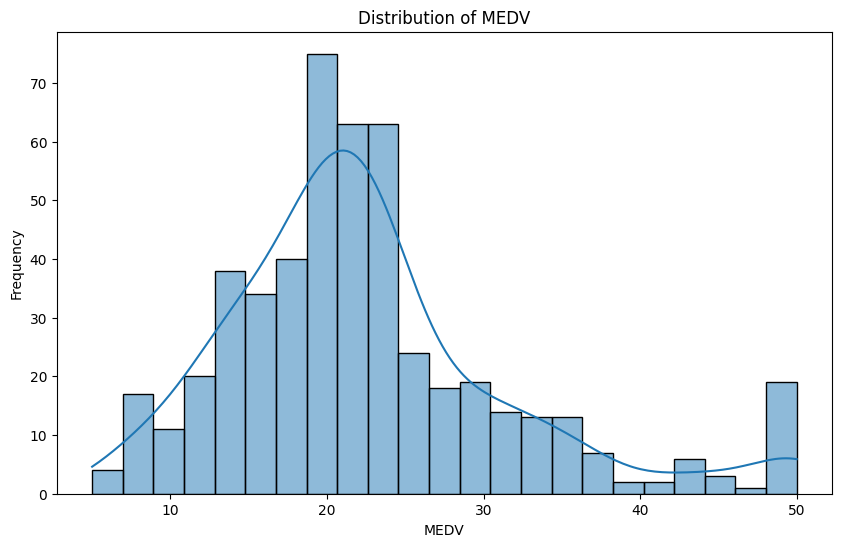

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(df["medv"], kde=True)

plt.title("Distribution of MEDV")
plt.xlabel("MEDV")
plt.ylabel("Frequency")

plt.show()

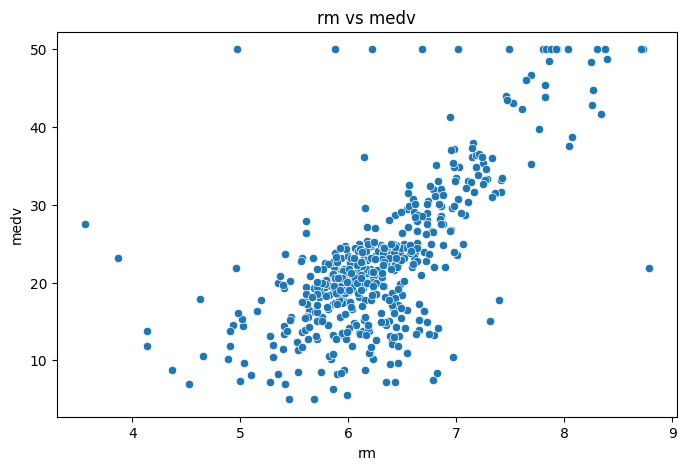

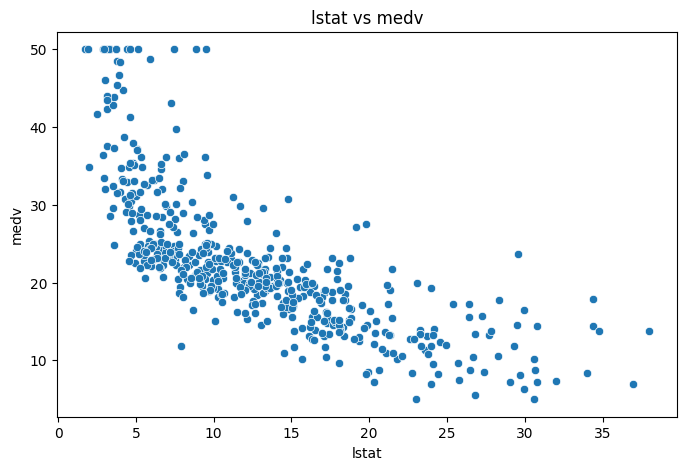

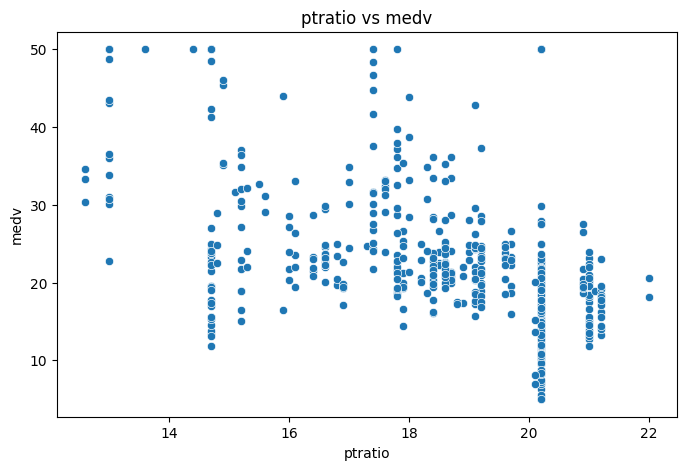

In [ ]:
selected_features = ["rm", "lstat", "ptratio"]

for feature in selected_features:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df[feature], y=df["medv"])
    plt.title(f"{feature} vs medv")
    plt.xlabel(feature)
    plt.ylabel("medv")
    plt.show()

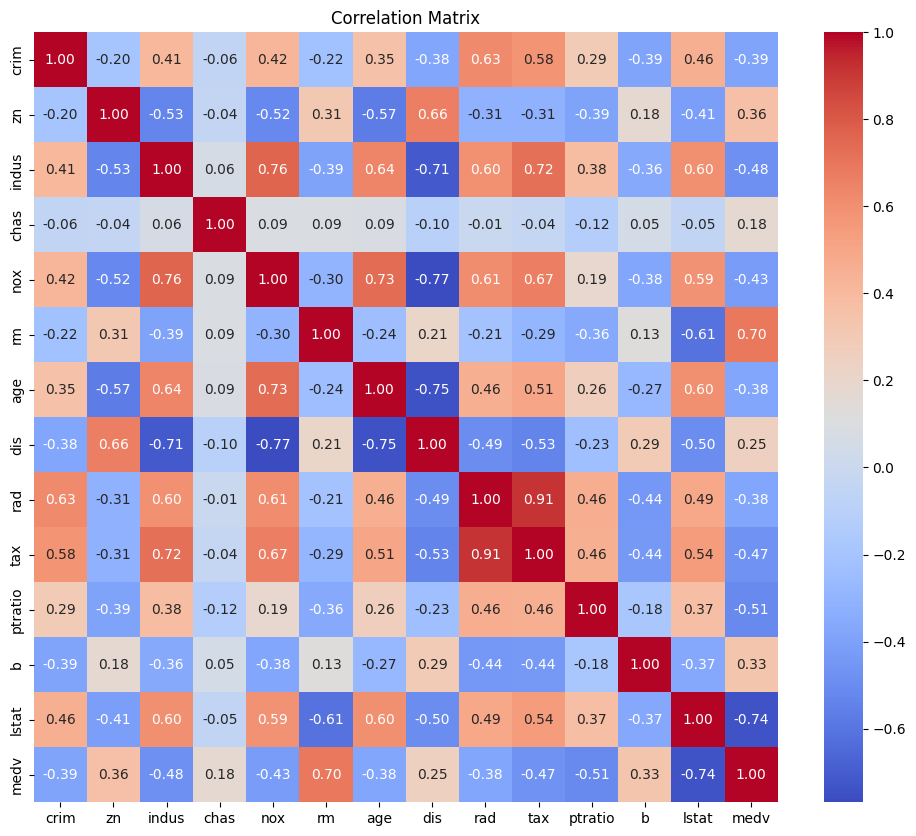

In [ ]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
medv_correlation = correlation_matrix["medv"].sort_values(
    ascending=False
)

print("Correlation of attributes with medv:")
print(medv_correlation)

print("\nStrongest relationships with medv:")

print(
    medv_correlation.drop("medv")
    .abs()
    .sort_values(ascending=False)
)

Correlation of attributes with medv:
medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64

Strongest relationships with medv:
lstat      0.737663
rm         0.695360
ptratio    0.507787
indus      0.483725
tax        0.468536
nox        0.427321
crim       0.388305
rad        0.381626
age        0.376955
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
Name: medv, dtype: float64


In [ ]:
df = df.drop_duplicates()
df = df.dropna()

X = df.drop("medv", axis=1)

y = df["medv"]

print("Predictor variables:")
print(X.head())

print("\nTarget variable:")
print(y.head())

print("\nShape of X:", X.shape)

print("Shape of y:", y.shape)

Predictor variables:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio       b  lstat
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3  396.90   4.98
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8  396.90   9.14
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8  392.83   4.03
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7  394.63   2.94
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7  396.90   5.33

Target variable:
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64

Shape of X: (506, 13)
Shape of y: (506,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])

print("Testing samples:", X_test.shape[0])

Training samples: 404
Testing samples: 102


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

coefficients = pd.DataFrame({
    "Attribute": X.columns,
    "Coefficient": model.coef_
})

print("Regression coefficients:")

print(coefficients.to_string(index=False))

print("\nIntercept:")

print(model.intercept_)

Regression coefficients:
Attribute  Coefficient
     crim    -0.113056
       zn     0.030110
    indus     0.040381
     chas     2.784438
      nox   -17.202633
       rm     4.438835
      age    -0.006296
      dis    -1.447865
      rad     0.262430
      tax    -0.010647
  ptratio    -0.915456
        b     0.012351
    lstat    -0.508571

Intercept:
30.24675099392366


In [ ]:
coefficients = pd.DataFrame({
    "Attribute": X.columns,
    "Coefficient": model.coef_
})

print("Regression coefficients:")

print(coefficients.to_string(index=False))

print("\nIntercept:")

print(model.intercept_)

Regression coefficients:
Attribute  Coefficient
     crim    -0.113056
       zn     0.030110
    indus     0.040381
     chas     2.784438
      nox   -17.202633
       rm     4.438835
      age    -0.006296
      dis    -1.447865
      rad     0.262430
      tax    -0.010647
  ptratio    -0.915456
        b     0.012351
    lstat    -0.508571

Intercept:
30.24675099392366


In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mae = mean_absolute_error(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)

test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(y_train, y_train_pred)

test_r2 = r2_score(y_test, y_test_pred)

n_train = len(y_train)

p = X_train.shape[1]

train_adjusted_r2 = 1 - (
    (1 - train_r2) * (n_train - 1) /
    (n_train - p - 1)
)

n_test = len(y_test)

test_adjusted_r2 = 1 - (
    (1 - test_r2) * (n_test - 1) /
    (n_test - p - 1)
)

metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score",
        "Adjusted R2"
    ],
    "Training": [
        train_mae,
        train_mse,
        train_rmse,
        train_r2,
        train_adjusted_r2
    ],
    "Testing": [
        test_mae,
        test_mse,
        test_rmse,
        test_r2,
        test_adjusted_r2
    ]
})

print(metrics.to_string(index=False))

     Metric  Training   Testing
        MAE  3.314772  3.189092
        MSE 21.641413 24.291119
       RMSE  4.652033  4.928602
   R2 Score  0.750886  0.668759
Adjusted R2  0.742582  0.619826


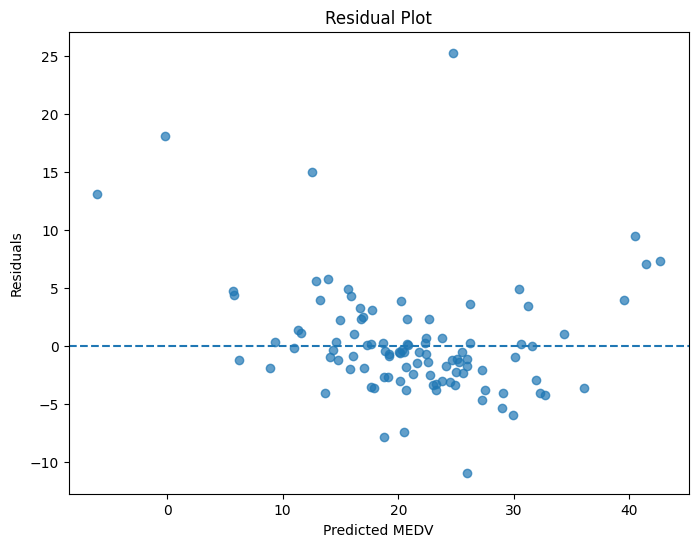

In [ ]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_test_pred, residuals, alpha=0.7)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted MEDV")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

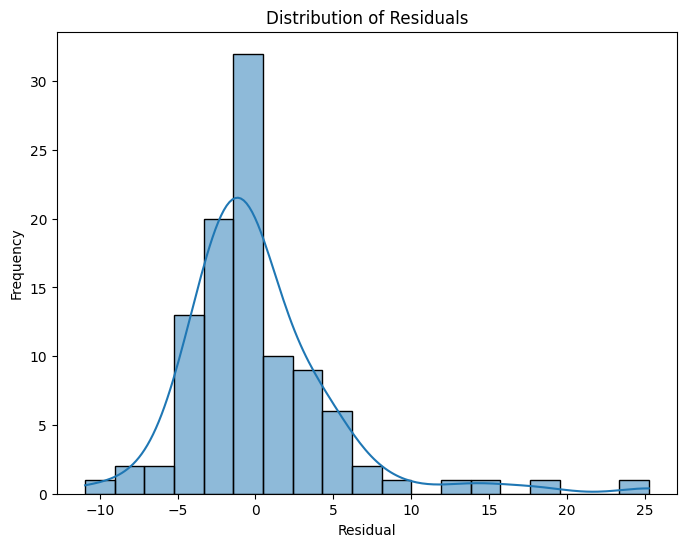

In [ ]:
plt.figure(figsize=(8, 6))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

In [ ]:
coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

print("Largest positive coefficients:")

print(
    coefficients.sort_values(
        "Coefficient",
        ascending=False
    ).head(5).to_string(index=False)
)

print("\nLargest negative coefficients:")

print(
    coefficients.sort_values(
        "Coefficient"
    ).head(5).to_string(index=False)
)

Largest positive coefficients:
Attribute  Coefficient  Absolute Coefficient
       rm     4.438835              4.438835
     chas     2.784438              2.784438
      rad     0.262430              0.262430
    indus     0.040381              0.040381
       zn     0.030110              0.030110

Largest negative coefficients:
Attribute  Coefficient  Absolute Coefficient
      nox   -17.202633             17.202633
      dis    -1.447865              1.447865
  ptratio    -0.915456              0.915456
    lstat    -0.508571              0.508571
     crim    -0.113056              0.113056


In [ ]:
print("Training R2 Score:", round(train_r2, 4))

print("Testing R2 Score:", round(test_r2, 4))

r2_difference = train_r2 - test_r2

print(
    "Difference between training and testing R2:",
    round(r2_difference, 4)
)

if r2_difference > 0.10:
    print("The model may show signs of overfitting.")

elif train_r2 < 0.60 and test_r2 < 0.60:
    print("The model may show signs of underfitting.")

else:
    print(
        "There is no strong evidence of overfitting "
        "based on the R2 comparison."
    )

Training R2 Score: 0.7509
Testing R2 Score: 0.6688
Difference between training and testing R2: 0.0821
There is no strong evidence of overfitting based on the R2 comparison.


In [ ]:
improvement_suggestions = [
    "Use Ridge and Lasso Regression.",
    "Perform feature selection.",
    "Handle influential outliers.",
    "Use cross-validation.",
    "Compare nonlinear regression algorithms.",
    "Apply suitable feature transformations."
]

for i, suggestion in enumerate(
    improvement_suggestions, start=1
):
    print(f"{i}. {suggestion}")

1. Use Ridge and Lasso Regression.
2. Perform feature selection.
3. Handle influential outliers.
4. Use cross-validation.
5. Compare nonlinear regression algorithms.
6. Apply suitable feature transformations.


In [ ]:
print("========== FINAL SUMMARY ==========")

print("Number of samples:", len(df))

print("Number of features:", X.shape[1])

print("Test MAE:", round(test_mae, 4))

print("Test MSE:", round(test_mse, 4))

print("Test RMSE:", round(test_rmse, 4))

print("Test R2 Score:", round(test_r2, 4))

print("Test Adjusted R2:", round(test_adjusted_r2, 4))

print("\nMultiple Linear Regression analysis completed successfully.")

========== FINAL SUMMARY ==========
Number of samples: 506
Number of features: 13
Test MAE: 3.1891
Test MSE: 24.2911
Test RMSE: 4.9286
Test R2 Score: 0.6688
Test Adjusted R2: 0.6198

Multiple Linear Regression analysis completed successfully.


INTERPRETATION


The model predicts house prices using 13 housing features.

R² = 0.669: The model explains about 66.9% of the variation in house prices.
MAE = 3.189: Average prediction error is about 3.19 units.
rm has a positive relationship with house price.
lstat has a negative relationship with house price.
The training and testing scores are reasonably close, so there is no strong sign of overfitting.

Conclusion: The model performs reasonably well but can be improved using feature selection, regularization, or other regression methods.